<a href="https://colab.research.google.com/github/awellos/ExploreAI/blob/main/PCA%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import keras
keras.datasets.mnist.load_data(path="mnist.npz")

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [ ]:
import numpy as np

# Assign the loaded data to variables
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data(path="mnist.npz")

The MNIST images are 28x28 pixels. For PCA, we need to flatten each image into a 1D vector.

In [ ]:
# Flatten the training images from 28x28 to 784 (28*28) pixels
x_train_flat = x_train.reshape(x_train.shape[0], -1)

print(f"Shape of original training data: {x_train.shape}")
print(f"Shape of flattened training data: {x_train_flat.shape}")

Shape of original training data: (60000, 28, 28)
Shape of flattened training data: (60000, 784)


Now, let's compute the covariance matrix of the flattened training data. Before computing the covariance, it's good practice to center the data by subtracting the mean.

In [ ]:
# Center the data by subtracting the mean
x_train_centered = x_train_flat - np.mean(x_train_flat, axis=0)

# Compute the covariance matrix
covariance_matrix = np.cov(x_train_centered, rowvar=False)

print(f"Shape of covariance matrix: {covariance_matrix.shape}")

Shape of covariance matrix: (784, 784)


Finally, we perform eigenvalue decomposition on the covariance matrix to find the principal components (eigenvectors) and their corresponding variances (eigenvalues).

In [ ]:
# Perform eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print(f"Shape of eigenvalues: {eigenvalues.shape}")
print(f"Shape of eigenvectors: {eigenvectors.shape}")
print("Top 5 eigenvalues:\n", eigenvalues[:5])
print("First eigenvector (principal component):\n", eigenvectors[:, 0])

Shape of eigenvalues: (784,)
Shape of eigenvectors: (784, 784)
Top 5 eigenvalues:
 [332724.66744657 243283.9390705  211507.36705827 184776.38586219
 166926.83131066]
First eigenvector (principal component):
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  1.13022998e-06  4.44987008e-06  2.19785960e-06  9.15774834e-08
 -5.55111512e-17 -2.77555756e-17  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  5.42101086e-20  0.00000000e+00
 -1.69406589e-21  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -8.27180613e-25  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -2.46332117e-07 -8.70394526e-07 -8.07828577e-06 -2.07899216e-05
 -2.74484784e-05 -4.43302472e-05 -7.14293297e-05 -9.03571728e-05
 -8.92534083e-05 -7.96187541e-05 -8.37900231e-05 -6.12003373e-05
 -3.32476102e-05 -3.18856916e-05 -1.84435794e-05  1.33003534e-05
  1.08540941

In [ ]:
# Select principal components
n_components = 2
principal_components = eigenvectors[:, :n_components]

# Flatten the test images
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# Center the test data using the mean of the training data
x_test_centered = x_test_flat - np.mean(x_train_flat, axis=0)

# Project the data onto the principal components
x_train_pca = x_train_centered @ principal_components
x_test_pca = x_test_centered @ principal_components
print("\nPCA training data shape:")
print(x_train_pca.shape)
print("PCA test data shape:")
print(x_test_pca.shape)


PCA training data shape:
(60000, 2)
PCA test data shape:
(10000, 2)


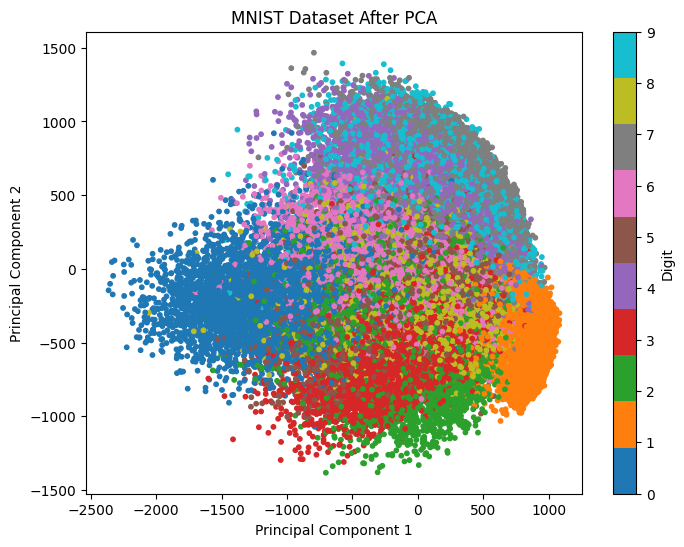

In [ ]:
# 7. Visualize the MNIST dataset in 2D
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    x_train_pca[:, 0],
    x_train_pca[:, 1],
    c=y_train, cmap="tab10", s=10
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST Dataset After PCA")
plt.colorbar(scatter, label="Digit")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 8. Train a classifier using the full dataset
model_full = LogisticRegression(
    max_iter=1000
)
model_full.fit(x_train_flat, y_train)
predictions_full = model_full.predict(x_test_flat)
accuracy_full = accuracy_score(
    y_test, predictions_full
)
print("\nAccuracy using full dataset:")
print(accuracy_full)


Accuracy using full dataset:
0.921


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# 9. Train a classifier using PCA-reduced data
model_pca = LogisticRegression(
    max_iter=1000
)
model_pca.fit(x_train_pca, y_train)
predictions_pca = model_pca.predict(x_test_pca)
accuracy_pca = accuracy_score(
    y_test,
    predictions_pca
)
print("\nAccuracy using PCA-reduced data:")
print(accuracy_pca)


Accuracy using PCA-reduced data:
0.4472


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# 10. Compare the results
print("\n----- Comparison -----")

print("Full dataset accuracy:", accuracy_full)
print("PCA accuracy:", accuracy_pca)

print("\nOriginal number of features:", x_train.shape[1])
print("Number of PCA features:", x_train_pca.shape[1])


----- Comparison -----
Full dataset accuracy: 0.921
PCA accuracy: 0.4472

Original number of features: 28
Number of PCA features: 2
